### Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image  import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
model = tf.keras.models.load_model('trained_model.keras')

In [4]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 conv2d_9 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 conv2d_11 (Conv2D)          (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                  

### Visualizing Single Image of Test Set

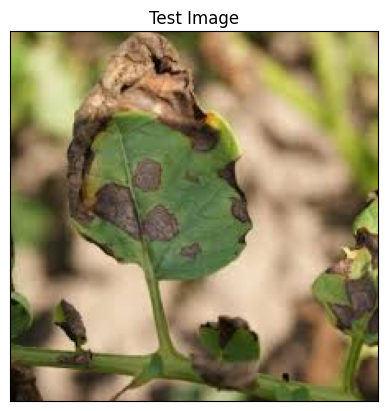

In [23]:
import cv2
image_path = r'test\test\images.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [33]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr])#convert single image to a batch
print(input_arr.shape)


(1, 128, 128, 3)


In [34]:
prediction= model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 67ms/step


(array([[7.2234936e-20, 8.1215921e-20, 3.5793317e-18, 5.1010310e-19,
         6.3899394e-24, 6.9179211e-11, 6.3087504e-17, 4.2511496e-01,
         4.0293617e-09, 4.7231999e-01, 1.9394268e-07, 1.2589729e-14,
         6.5910475e-15, 1.5235466e-10, 9.2231922e-17, 3.9458821e-17,
         3.0777113e-11, 6.0160147e-18, 6.6045948e-13, 1.2146647e-19,
         7.1300909e-18, 5.0516735e-18, 6.1716422e-17, 5.7080607e-22,
         6.2055176e-25, 3.6483139e-10, 1.0256219e-01, 4.5684161e-28,
         2.7018660e-23, 5.7591501e-12, 2.6415767e-06, 5.5755838e-20,
         2.7384016e-15, 6.7897872e-18, 6.3796317e-18, 1.9413776e-18,
         1.0644391e-21, 7.1160555e-22]], dtype=float32),
 (1, 38))

In [35]:
result_index=np.argmax(prediction)
result_index

9

In [36]:
class_name= ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

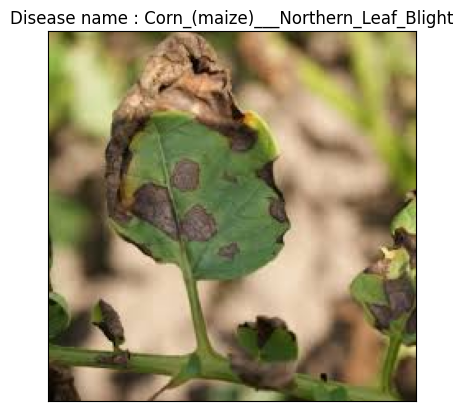

'Corn_(maize)___Northern_Leaf_Blight'

In [37]:
model_prediction= class_name[result_index]
plt.imshow(img)
plt.title(f"Disease name : {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()
model_prediction